# GlowWise AI - Data Preprocessing Pipeline 🧪

This notebook documents and executes the data preprocessing pipeline designed to prepare the Sephora skincare review dataset for machine learning. 

### Why Preprocessing Matters
Raw user reviews are unstructured, contain HTML/markdown artifacts, varying casings, and missing metadata values. More importantly, the dataset exhibits a severe class imbalance (~82% positive ratings) and multiple critical data leakage columns.

Preprocessing ensures:
1. **Target Engineering**: Constructing clean 3-class sentiment (`sentiment_label`) and binary satisfaction (`high_satisfaction`) targets.
2. **Leakage Elimination**: Removing columns like `rating` and `is_recommended` which create trivial model shortcuts, and post-review interaction statistics (`helpfulness`, feedback counts) which are unavailable at inference time.
3. **Data Completeness**: Handling missing values using median imputation for prices, "unknown" for user skin attributes, and empty strings for text metadata.
4. **Text Uniformity**: Cleaning text (lowercasing, whitespace cleanup) and merging reviews to form a single, unified text corpus (`combined_text`).
5. **Feature Engineering**: Creating character count (`text_length`) and word count (`word_count`) features.
6. **Efficiency**: Sampling a stratified 100,000 review dataset (`glowwise_reviews_sample_100k.csv`) to speed up model experiments while keeping the distribution identical to the full dataset.


In [1]:
import sys
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust styling for clean premium visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#332633'
plt.rcParams['axes.labelcolor'] = '#332633'
plt.rcParams['xtick.color'] = '#332633'
plt.rcParams['ytick.color'] = '#332633'

# Premium color variables matching the GlowWise wellness theme
COLOR_PLUM = '#3B243B'
COLOR_GOLD = '#C39B6F'
COLOR_ROSE = '#E8D3C4'
COLOR_LIGHT_PLUM = '#5C3D5C'
COLOR_CREAM = '#FCFAF7'
COLOR_MUTED = '#6E5C6E'

# Resolve project root path dynamically
current_path = Path.cwd().resolve()
root_dir = None
for parent in [current_path] + list(current_path.parents):
    if (parent / "README.md").exists():
        root_dir = parent
        break
if root_dir is None:
    root_dir = current_path.parent if 'notebooks' in current_path.name else current_path

sys.path.append(str(root_dir / "ml" / "src"))
from load_data import get_data_dir

# Set output path for figures
figures_dir = root_dir / "ml" / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


## 1. Load Audited Preprocessed Dataset

To keep execution efficient and fast, we load the **stratified 100k sample** generated by our preprocessing pipeline. Because this sample is stratified based on the target variable (`high_satisfaction`), its distribution perfectly reflects the full 1.09-million reviews dataset.


In [2]:
data_dir = get_data_dir()
sample_path = data_dir / "processed" / "glowwise_reviews_sample_100k.csv"

print(f"Loading preprocessed sample: {sample_path.name}")
df = pd.read_csv(sample_path)
# Fill missing text fields that pandas parsed as NaN back to empty strings
for col in ["review_title", "review_text", "combined_text", "ingredients"]:
    if col in df.columns:
        df[col] = df[col].fillna("")
print(f"Dataset shape: {df.shape}")
df.head(3)


Loading preprocessed sample: glowwise_reviews_sample_100k.csv


Dataset shape: (100000, 20)


C:\Users\mahta\AppData\Local\Temp\ipykernel_7372\2075758584.py:5: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(sample_path)


,product_id,author_id,review_text,review_title,combined_text,text_length,word_count,skin_type,skin_tone,hair_color,eye_color,brand_name,product_name,primary_category,secondary_category,tertiary_category,price_usd,ingredients,sentiment_label,high_satisfaction
0,P469213,5056917590,i was so grateful to receive this eye gel from...,,i was so grateful to receive this eye gel from...,622,115,combination,lightMedium,brown,brown,OLEHENRIKSEN,Wrinkle Blur Bakuchiol Eye Gel Crème,Skincare,Eye Care,Eye Creams & Treatments,52.0,"['Aqua/Water/Eau, Dimethicone, Glycerin, Neope...",positive,1
1,P433443,6523293961,i’m a sleeping mask junkie and i have to say t...,,i’m a sleeping mask junkie and i have to say t...,289,58,combination,fair,brown,green,belif,Aqua Bomb Sleeping Mask,Skincare,Moisturizers,Night Creams,38.0,"['Water, Dipropylene Glycol, Polyglycerin-3, 1...",positive,1
2,P453225,5806642306,this mask really works! the consistency is thi...,best lip mask on the market!,best lip mask on the market! this mask really ...,841,161,normal,fairLight,auburn,brown,Tatcha,The Kissu Lip Mask,Skincare,Lip Balms & Treatments,unknown,29.0,"['Triisostearin, Polyglyceryl-2 Triisostearate...",positive,1


## 2. Target Variables & Class Distributions

We engineered two primary target variables:
- **`high_satisfaction`**: Binary indicator where rating 4-5 is mapped to `1` (High satisfaction) and rating 1-3 is mapped to `0` (Low/Medium satisfaction).
- **`sentiment_label`**: 3-class target classifying reviews into `positive`, `neutral`, and `negative`.

Let's look at the counts and percentages.


In [3]:
print("=== High Satisfaction (Binary Target) ===")
hs_counts = df["high_satisfaction"].value_counts()
hs_pcts = df["high_satisfaction"].value_counts(normalize=True) * 100
for idx in hs_counts.index:
    print(f"Class {idx}: {hs_counts[idx]:,} reviews ({hs_pcts[idx]:.2f}%)")

print("\n=== Sentiment Label (3-Class Target) ===")
sent_counts = df["sentiment_label"].value_counts()
sent_pcts = df["sentiment_label"].value_counts(normalize=True) * 100
for idx in sent_counts.index:
    print(f"Class {idx}: {sent_counts[idx]:,} reviews ({sent_pcts[idx]:.2f}%)")


=== High Satisfaction (Binary Target) ===
Class 1: 82,084 reviews (82.08%)
Class 0: 17,916 reviews (17.92%)

=== Sentiment Label (3-Class Target) ===
Class positive: 82,084 reviews (82.08%)
Class negative: 10,418 reviews (10.42%)
Class neutral: 7,498 reviews (7.50%)


### Visualizing Class Distribution: High Satisfaction


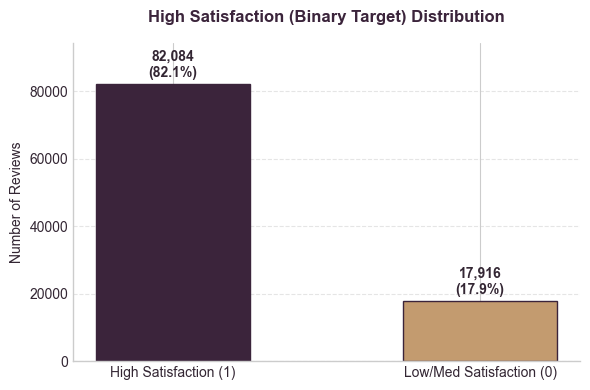

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['High Satisfaction (1)', 'Low/Med Satisfaction (0)'], 
              [hs_counts[1], hs_counts[0]], 
              color=[COLOR_PLUM, COLOR_GOLD], edgecolor=COLOR_PLUM, width=0.5)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,}\n({height/len(df)*100:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('High Satisfaction (Binary Target) Distribution', fontsize=12, pad=15, fontweight='bold', color=COLOR_PLUM)
ax.set_ylabel('Number of Reviews', fontsize=10)
ax.set_ylim(0, max(hs_counts) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(figures_dir / "preprocessing_high_satisfaction.png", dpi=150, bbox_inches='tight')
plt.show()


### Visualizing Class Distribution: Sentiment Label


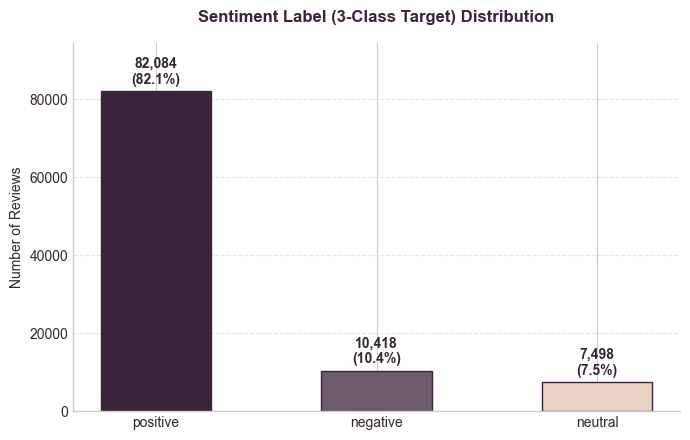

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
classes = ['positive', 'negative', 'neutral']
counts = [sent_counts.get(c, 0) for c in classes]

bars = ax.bar(classes, counts, color=[COLOR_PLUM, COLOR_MUTED, COLOR_ROSE], edgecolor=COLOR_PLUM, width=0.5)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,}\n({height/len(df)*100:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Sentiment Label (3-Class Target) Distribution', fontsize=12, pad=15, fontweight='bold', color=COLOR_PLUM)
ax.set_ylabel('Number of Reviews', fontsize=10)
ax.set_ylim(0, max(counts) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(figures_dir / "preprocessing_sentiment.png", dpi=150, bbox_inches='tight')
plt.show()


## 3. Data Leakage Verification

Data leakage occurs when models learn from features that won't be available at test-time, or that are trivial duplicates of the target.
We verify that all leakage-prone columns have been successfully removed:
- `rating` (used only to engineer the targets)
- `is_recommended`
- `helpfulness`
- `total_feedback_count`
- `total_pos_feedback_count`
- `total_neg_feedback_count`


In [6]:
leakage_cols = [
    "rating", "is_recommended", "helpfulness", 
    "total_feedback_count", "total_pos_feedback_count", "total_neg_feedback_count"
]

print("Verifying absence of leakage columns:")
found_leakage = [col for col in leakage_cols if col in df.columns]
if not found_leakage:
    print("✅ Success! No data leakage columns are present in the ML dataset.")
else:
    print(f"❌ Warning: The following leakage columns were found: {found_leakage}")


Verifying absence of leakage columns:
✅ Success! No data leakage columns are present in the ML dataset.


## 4. Missing Values Inspection After Imputation

The pipeline handled missing values as follows:
- **Text features** (`review_text`, `review_title`, `combined_text`, `ingredients`): replaced `NaN` with `""`.
- **User attribute categorical features** (`skin_type`, `skin_tone`, `hair_color`, `eye_color`): replaced `NaN` with `"unknown"`.
- **Numeric feature** (`price_usd`): coerced values to numeric and filled `NaN` with the median price from the training distribution ($39.00).

Let's check the missing value counts across all features.


In [7]:
missing_counts = df.isnull().sum()
print("Missing counts per column after preprocessing:")
print(missing_counts)


Missing counts per column after preprocessing:
product_id            0
author_id             0
review_text           0
review_title          0
combined_text         0
text_length           0
word_count            0
skin_type             0
skin_tone             0
hair_color            0
eye_color             0
brand_name            0
product_name          0
primary_category      0
secondary_category    0
tertiary_category     0
price_usd             0
ingredients           0
sentiment_label       0
high_satisfaction     0
dtype: int64


### Visualizing Data Completeness
We visualize the missing values after preprocessing. Every column should display 0 missing values.


C:\Users\mahta\AppData\Local\Temp\ipykernel_7372\3346222079.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(missing_counts.index, rotation=45, ha='right', fontsize=9)


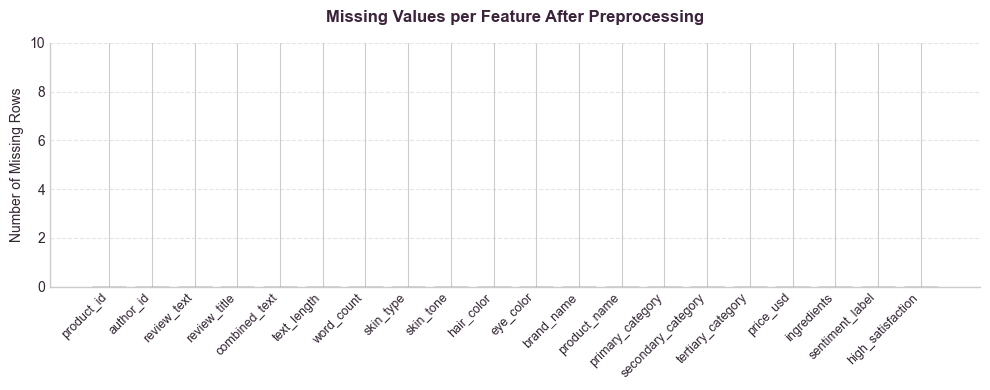

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(missing_counts.index, missing_counts.values, color=COLOR_PLUM, edgecolor=COLOR_PLUM)
ax.set_title('Missing Values per Feature After Preprocessing', fontsize=12, pad=15, fontweight='bold', color=COLOR_PLUM)
ax.set_ylabel('Number of Missing Rows', fontsize=10)
ax.set_xticklabels(missing_counts.index, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 10) # Set a low limit since all values are 0
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(figures_dir / "preprocessing_missing_values_after.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Text length and Word Count Analysis

We engineered two features from `combined_text`:
- `text_length`: Number of characters.
- `word_count`: Number of words.

Let's evaluate their statistical summaries.


In [9]:
df[['text_length', 'word_count']].describe()

,text_length,word_count
count,100000.000000,100000.000000
mean,334.283280,62.894360
std,234.467858,44.031741
min,20.000000,2.000000
25%,183.000000,34.000000
50%,277.000000,52.000000
75%,419.000000,79.000000
max,5538.000000,984.000000


### Visualizing Text Length Distribution
We display a histogram showing the distribution of review character lengths. Since some reviews can be extremely long, we clip the x-axis at 1,500 characters for readability.


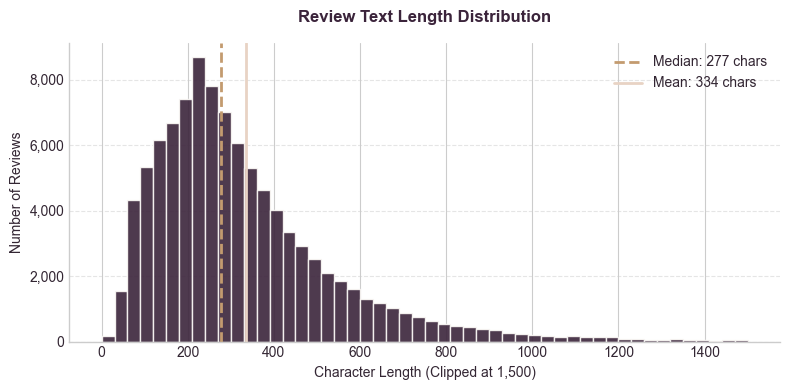

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['text_length'], bins=50, range=(0, 1500), color=COLOR_PLUM, edgecolor=COLOR_CREAM, alpha=0.9)
ax.axvline(df['text_length'].median(), color=COLOR_GOLD, linestyle='--', linewidth=2, 
           label=f'Median: {df["text_length"].median():.0f} chars')
ax.axvline(df['text_length'].mean(), color=COLOR_ROSE, linestyle='-', linewidth=2, 
           label=f'Mean: {df["text_length"].mean():.0f} chars')

ax.set_title('Review Text Length Distribution', fontsize=12, pad=15, fontweight='bold', color=COLOR_PLUM)
ax.set_xlabel('Character Length (Clipped at 1,500)', fontsize=10)
ax.set_ylabel('Number of Reviews', fontsize=10)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Format y-axis with comma separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.savefig(figures_dir / "preprocessing_text_length.png", dpi=150, bbox_inches='tight')
plt.show()


## 6. Summary of final ML-ready columns

Here is a summary of the 20 columns saved in the processed files, categorized by their roles in model training.

| Column Name | Data Type | Role | Imputation Strategy |
| :--- | :--- | :--- | :--- |
| **`product_id`** | string | Safe Identifier | - |
| **`author_id`** | string | Safe Identifier | - |
| **`review_text`** | string | Text Feature | Filled with `""` |
| **`review_title`** | string | Text Feature | Filled with `""` |
| **`combined_text`** | string | Engineered Text Feature | Dropped if empty |
| **`text_length`** | integer | Engineered Numeric Feature | Calculated |
| **`word_count`** | integer | Engineered Numeric Feature | Calculated |
| **`skin_type`** | string | Categorical Feature | Filled with `"unknown"` |
| **`skin_tone`** | string | Categorical Feature | Filled with `"unknown"` |
| **`hair_color`** | string | Categorical Feature | Filled with `"unknown"` |
| **`eye_color`** | string | Categorical Feature | Filled with `"unknown"` |
| **`brand_name`** | string | Categorical Feature | Filled with `"unknown"` |
| **`product_name`** | string | Categorical Feature | Filled with `"unknown"` |
| **`primary_category`** | string | Categorical Feature | Filled with `"unknown"` |
| **`secondary_category`** | string | Categorical Feature | Filled with `"unknown"` |
| **`tertiary_category`** | string | Categorical Feature | Filled with `"unknown"` |
| **`price_usd`** | float | Numeric Feature | Filled with median ($39.00) |
| **`ingredients`** | string | Text Feature | Filled with `""` |
| **`sentiment_label`** | string | 3-Class Target | Engineered |
| **`high_satisfaction`** | integer | Binary Target | Engineered |


## 7. Next Steps: Baseline Model Training 🚀

Now that the data has been preprocessed:
1. Leakage columns have been removed.
2. Missing values are filled.
3. Target distributions and sampling are finalized.

We are ready to move to the **`feat/baseline-model`** branch, where we will:
* Set up a text vectorization pipeline (TF-IDF vectorizer).
* Train a fast baseline classification model (Logistic Regression or Linear SVM).
* Formulate baseline metrics (Macro-F1, ROC-AUC) to address the class imbalance.
